# Tabular Deep Learning: US Firm Characteristics

**Docker image**: `ml4t`

This notebook tests whether a rank-1 adapter MLP ensemble extracts nonlinear
structure from 57 monthly firm characteristics. It evaluates one declared
label at a time across the canonical walk-forward folds. The 2016 holdout
remains sealed for the final selected strategy.

**Learning Objectives**:
- Compare three TabM capacity settings on a large cross-sectional panel
- Diagnose how validation IC changes across epoch checkpoints
- Distinguish a discrete classification target from its continuous IC target
- Register every configuration for downstream strategy selection

**Book Reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives)

**Prerequisites**: `03_financial_features.py`, [`05_linear`](05_linear.ipynb),
[`06_gbm`](06_gbm.ipynb)

In [1]:
"""TabM walk-forward cross-validation and registry integration."""

import warnings

import polars as pl
import yaml
from IPython.display import Markdown, display
from matplotlib import pyplot as plt

from case_studies.utils.tabular_dl import run_tabm_cv, tabm_runtime_spec
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False  # Set True to renew content-addressed training results
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
BATCH_SIZE = 4096
SEED = 42

## 1. Resolve the Execution Contract

The production setup fixes the CUDA backend and host thread count. These
inputs, the seed, and strict deterministic-algorithm mode participate in the
training hash, so a materially different execution cannot alias this result.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

tabm_setup = setup.get("modeling", {}).get("tabular_dl", {})
MODELS = tabm_setup.get("models", ["tabm"])
DEVICE = str(tabm_setup["device"]).lower()
NUM_THREADS = int(tabm_setup.get("num_threads", 8))
RUNTIME_SPEC = tabm_runtime_spec(DEVICE, seed=SEED, num_threads=NUM_THREADS)
set_global_seeds(SEED)

print(
    f"Case study: {CASE_STUDY_ID} | Label: {PRIMARY_LABEL} | "
    f"Device: {DEVICE} | threads: {NUM_THREADS} | seed: {SEED}"
)

Case study: us_firm_characteristics | Label: fwd_ret_1m | Device: cuda | threads: 8 | seed: 42


## 2. Load the Modeling Panel

The loader joins financial and fold-specific temporal features while preserving
the canonical `timestamp` and `symbol` keys. For classification, it also carries
the continuous return used for cross-sectional IC evaluation.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits[: MAX_FOLDS or None]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(
    f"Fit target: {label_col} | IC target: {mds.eval_label_col or label_col} | "
    f"Task: {mds.task_type} | Folds: {len(splits)}"
)

Dataset: 804,530 rows × 57 features
Fit target: fwd_ret_1m | IC target: fwd_ret_1m | Task: regression | Folds: 10


Missing-value rates reveal the preprocessing burden before fitting. Imputation
and standardization are learned separately within each training fold.

In [5]:
diagnostics = dataset.select(
    pl.len().alias("rows"),
    pl.col(entity_col).n_unique().alias("entities"),
    pl.col(label_col).null_count().alias("missing_fit_targets"),
    pl.concat_list([pl.col(name).is_null().mean() for name in feature_names])
    .list.mean()
    .alias("mean_feature_missing_rate"),
)
diagnostics

rows,entities,missing_fit_targets,mean_feature_missing_rate
u32,u32,u32,f64
804530,9861,0,0.0


## 3. Declare the TabM Grid

The three presets increase hidden width and ensemble membership together. The
epoch budget is held fixed so the comparison isolates capacity rather than
training duration.

In [6]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="tabular_dl")
configs = [cfg for cfg in configs if cfg["config_name"].startswith(tuple(MODELS))]

for cfg in configs:
    cfg["n_epochs"] = N_EPOCHS
    cfg["batch_size"] = BATCH_SIZE

config_grid = pl.DataFrame(
    {
        "config": [cfg["config_name"] for cfg in configs],
        "hidden_units": [cfg["params"]["hidden_dim"] for cfg in configs],
        "ensemble_members": [cfg["params"]["n_members"] for cfg in configs],
        "dropout": [cfg["params"]["dropout"] for cfg in configs],
        "epochs": [cfg["n_epochs"] for cfg in configs],
    }
)
print(f"Grid: {len(configs)} configs × {len(splits)} folds = {len(configs) * len(splits)} fits")
config_grid

Grid: 3 configs × 10 folds = 30 fits


config,hidden_units,ensemble_members,dropout,epochs
str,i64,i64,f64,i64
"""tabm_s""",64,4,0.1,100
"""tabm_m""",128,8,0.1,100
"""tabm_l""",256,16,0.1,100


## 4. Run Walk-Forward Validation

Each fold fits its own median imputer and scaler on training observations only.
TabM trains to the declared epoch budget and records predictions at every
checkpoint. Configuration and checkpoint ranking use mean per-timestamp rank IC.

In [7]:
result = run_tabm_cv(
    dataset.to_pandas(),
    splits,
    configs=configs,
    n_features=n_features,
    feature_names=feature_names,
    label_col=label_col,
    eval_label_col=mds.eval_label_col,
    task_type=mds.task_type,
    class_values=mds.class_values or None,
    date_col=date_col,
    entity_col=entity_col,
    device=DEVICE,
    num_threads=NUM_THREADS,
    seed=SEED,
    save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
    register=True,
    case_study=CASE_STUDY_ID,
    notebook="07_tabular_dl",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
)

  REUSE tabm_s                    (complete (hash=96828f671f0d), split=validation)


  REUSE tabm_m                    (complete (hash=a8e79d4fc02a), split=validation)
  REUSE tabm_l                    (complete (hash=de27e859c519), split=validation)
All configs complete; replaying content-addressed predictions.

  Best: tabm_l @ epoch 25 (IC=+0.0343)


  Saved TabM artifacts for fwd_ret_1m


## 5. Compare Configurations

Each row reports the checkpoint selected from the same canonical validation
surface. All configurations remain available to downstream backtests; the IC
leader is diagnostic rather than the final trading carrier.

In [8]:
grid_results = result["grid_results"]
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
best_ic = result["best_ic"]
curves = result["all_learning_curves"]

summary = pl.DataFrame(
    {
        "config": [row["config_name"] for row in grid_results],
        "best_epoch": [row["best_epoch"] for row in grid_results],
        "ic_mean": [row["best_ic"] for row in grid_results],
        "elapsed_seconds": [row["elapsed_s"] for row in grid_results],
        "cached": [row.get("cached", False) for row in grid_results],
    }
)
summary

config,best_epoch,ic_mean,elapsed_seconds,cached
str,i64,f64,f64,bool
"""tabm_l""",25,0.03427,0.0,true
"""tabm_m""",25,0.030503,0.0,true
"""tabm_s""",25,0.03036,0.0,true


### Validation IC across the capacity grid

Error bars show the standard deviation of the monthly IC series. They measure
temporal dispersion, not uncertainty around the mean.

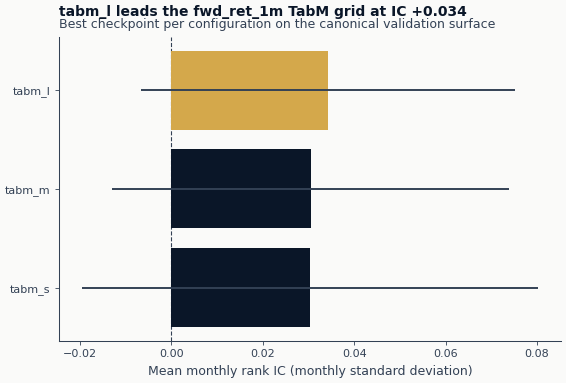

In [9]:
if best_name:
    selected_epochs = summary.select(
        "config",
        pl.col("best_epoch").alias("epoch"),
    )
    dispersion = curves.join(selected_epochs, on=["config", "epoch"]).select(
        "config",
        "ic_std",
    )
    plot_summary = summary.join(dispersion, on="config", how="left").sort("ic_mean")
    colors = [
        COLORS["amber"] if name == best_name else COLORS["blue"]
        for name in plot_summary["config"].to_list()
    ]
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
    ax.barh(
        plot_summary["config"].to_list(),
        plot_summary["ic_mean"].to_list(),
        xerr=plot_summary["ic_std"].to_list(),
        color=colors,
        ecolor=COLORS["neutral"],
        capsize=3,
    )
    zero_line(ax, axis="x")
    ax.set_xlabel("Mean monthly rank IC (monthly standard deviation)")
    ax.set_ylabel("")
    add_message_title(
        ax,
        f"{best_name} leads the {PRIMARY_LABEL} TabM grid at IC {best_ic:+.3f}",
        subtitle="Best checkpoint per configuration on the canonical validation surface",
    )
    fig.tight_layout()
    plt.show()

## 6. Inspect Checkpoint Stability

A broad plateau is more credible than a narrow peak. The curves show whether
additional epochs improve the validation signal or merely increase variance.

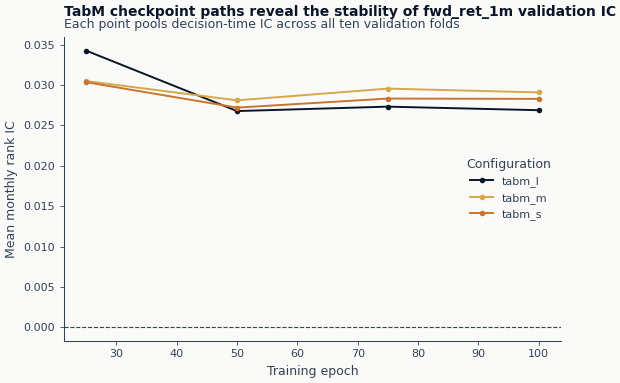

In [10]:
if not curves.is_empty():
    palette = [COLORS["blue"], COLORS["amber"], COLORS["copper"]]
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
    for name, color in zip(summary["config"].to_list(), palette, strict=False):
        curve = curves.filter(pl.col("config") == name).sort("epoch")
        epochs = curve["epoch"].to_numpy()
        means = curve["ic_mean"].to_numpy()
        ax.plot(epochs, means, color=color, marker="o", label=name)
    zero_line(ax, axis="y")
    ax.set_xlabel("Training epoch")
    ax.set_ylabel("Mean monthly rank IC")
    ax.legend(title="Configuration", frameon=False)
    add_message_title(
        ax,
        f"TabM checkpoint paths reveal the stability of {PRIMARY_LABEL} validation IC",
        subtitle="Each point pools decision-time IC across all ten validation folds",
    )
    fig.tight_layout()
    plt.show()

## 7. Confirm Coverage and Fold Results

Every registered checkpoint must cover the complete validation surface. Fold
metrics are diagnostic summaries; the configuration ranking above uses the
timestamp-level IC series rather than an average of fold statistics.

In [11]:
predictions = result["predictions"]
all_predictions = result["all_predictions"]
fold_metrics = result["fold_metrics"]

coverage = pl.DataFrame(
    {
        "selected_prediction_rows": [predictions.height],
        "all_checkpoint_rows": [all_predictions.height],
        "validation_months": [predictions[date_col].n_unique() if predictions.height else 0],
        "folds": [predictions["fold_id"].n_unique() if predictions.height else 0],
    }
)
coverage

selected_prediction_rows,all_checkpoint_rows,validation_months,folds
i64,i64,i64,i64
252008,3024096,110,10


In [12]:
fold_metrics

fold_id,ic_mean,n_test
i64,f64,i64
0,0.066875,22646
1,0.031983,23236
2,0.022131,24092
3,0.033881,24759
4,0.031176,24870
5,0.029456,25285
6,0.055395,25523
7,0.035693,25834
8,0.024565,26885


## 8. Key Takeaways

The summary below is generated from this execution, keeping every numeric claim
tied to visible output. Trading selection remains downstream: validation
backtests compare all registered configurations before the holdout is opened once.

In [13]:
if best_name:
    spread = float(summary["ic_mean"].max() - summary["ic_mean"].min())
    leader_curve = curves.filter(pl.col("config") == best_name).sort("epoch")
    final_ic = float(leader_curve["ic_mean"][-1])
    peak_to_final = best_ic - final_ic
    display(
        Markdown(
            f"- **Leader:** `{best_name}` reaches mean validation IC {best_ic:+.4f} at "
            f"epoch {best_epoch} for `{PRIMARY_LABEL}`.\n"
            f"- **Capacity sensitivity:** The best-checkpoint spread across the three "
            f"presets is {spread:.4f}.\n"
            f"- **Checkpoint stability:** The leader changes by {peak_to_final:+.4f} IC "
            f"between its selected and final checkpoints.\n"
            f"- **Coverage:** The selected checkpoint contains {predictions.height:,} "
            f"predictions across {predictions[date_col].n_unique()} validation months and "
            f"{predictions['fold_id'].n_unique()} folds.\n"
            "- **Limitation:** IC evaluates ranking quality before costs and portfolio "
            "constraints; the downstream sweep, not this diagnostic leader, selects the carrier.\n\n"
            "**Next:** [`08_latent_factors`](08_latent_factors.ipynb) tests whether structured "
            "factor representations add a complementary signal path. **Book:** Chapter 12.3."
        )
    )

- **Leader:** `tabm_l` reaches mean validation IC +0.0343 at epoch 25 for `fwd_ret_1m`.
- **Capacity sensitivity:** The best-checkpoint spread across the three presets is 0.0039.
- **Checkpoint stability:** The leader changes by +0.0074 IC between its selected and final checkpoints.
- **Coverage:** The selected checkpoint contains 252,008 predictions across 110 validation months and 10 folds.
- **Limitation:** IC evaluates ranking quality before costs and portfolio constraints; the downstream sweep, not this diagnostic leader, selects the carrier.

**Next:** [`08_latent_factors`](08_latent_factors.ipynb) tests whether structured factor representations add a complementary signal path. **Book:** Chapter 12.3.